Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

%matplotlib inline

Load Dataset

In [ ]:
df = pd.read_csv(
    "Sample - Superstore.csv",
    encoding="latin1"
)

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

Executive KPI Dashboard

In [ ]:
total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_orders = df['Order ID'].nunique()

total_customers = df['Customer ID'].nunique()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")

Total Sales: $2,297,201
Total Profit: $286,397
Total Orders: 5,009
Total Customers: 793


Revenue Trend Visualization

In [ ]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key='Order Date',
            freq='ME'
        )
    )['Sales']
    .sum()
    .reset_index()
)

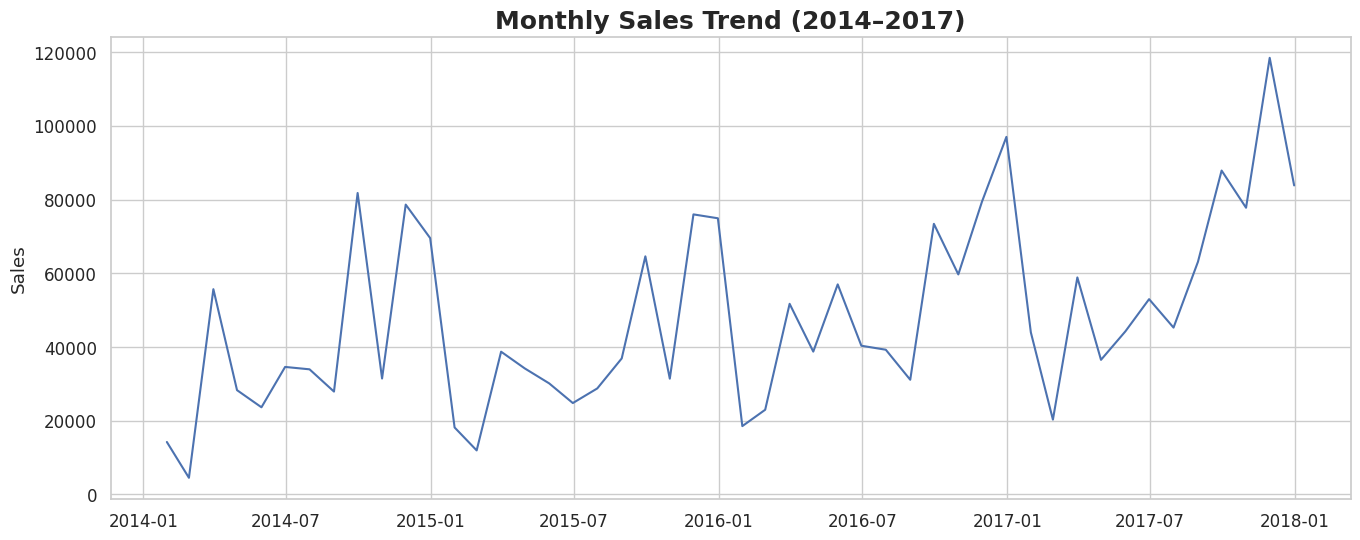

In [ ]:
plt.figure(figsize=(16,6))

sns.lineplot(
    data=monthly_sales,
    x='Order Date',
    y='Sales'
)

plt.title(
    'Monthly Sales Trend (2014–2017)',
    fontsize=18,
    weight='bold'
)

plt.xlabel('')
plt.ylabel('Sales')

plt.show()

delete,top10 bottom 10

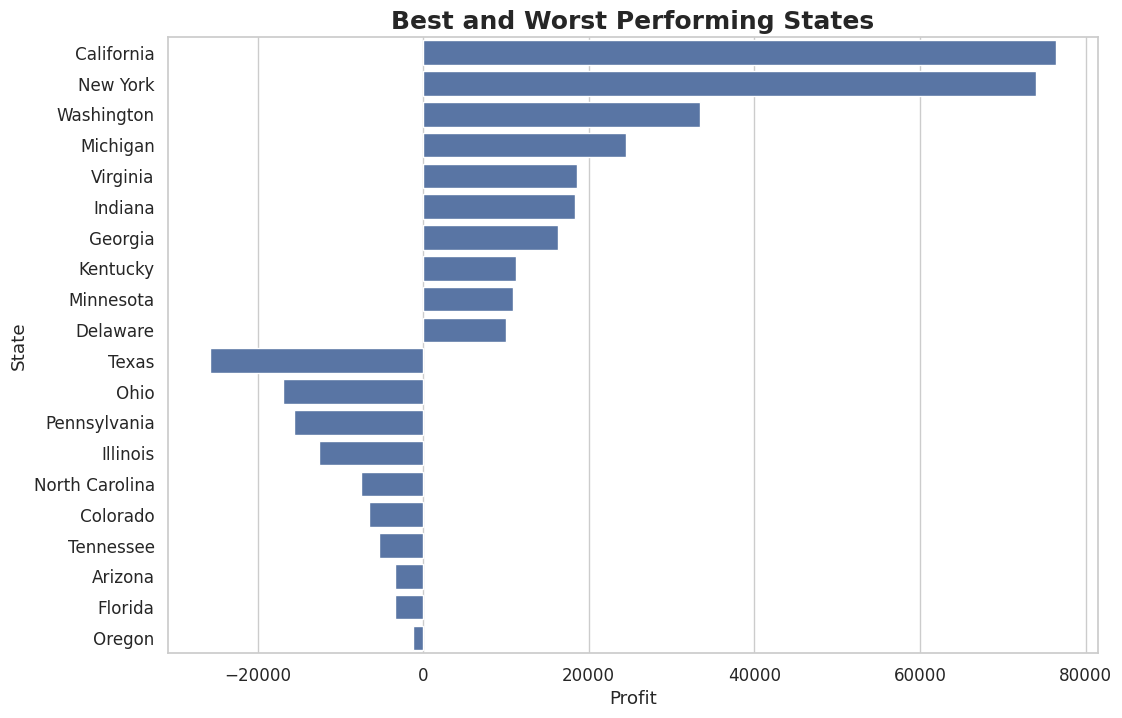

In [ ]:
state_compare = (
    df.groupby('State')
    .agg({
        'Profit':'sum'
    })
)

top_states = (
    state_compare
    .sort_values(
        'Profit',
        ascending=False
    )
    .head(10)
)

bottom_states = (
    state_compare
    .sort_values(
        'Profit'
    )
    .head(10)
)

comparison = pd.concat([
    top_states,
    bottom_states
])

plt.figure(figsize=(12,8))

sns.barplot(
    x='Profit',
    y=comparison.index,
    data=comparison.reset_index()
)

plt.title(
    'Best and Worst Performing States',
    fontsize=18,
    weight='bold'
)

plt.show()

Top 10 States by Profit

In [ ]:
state_profit = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

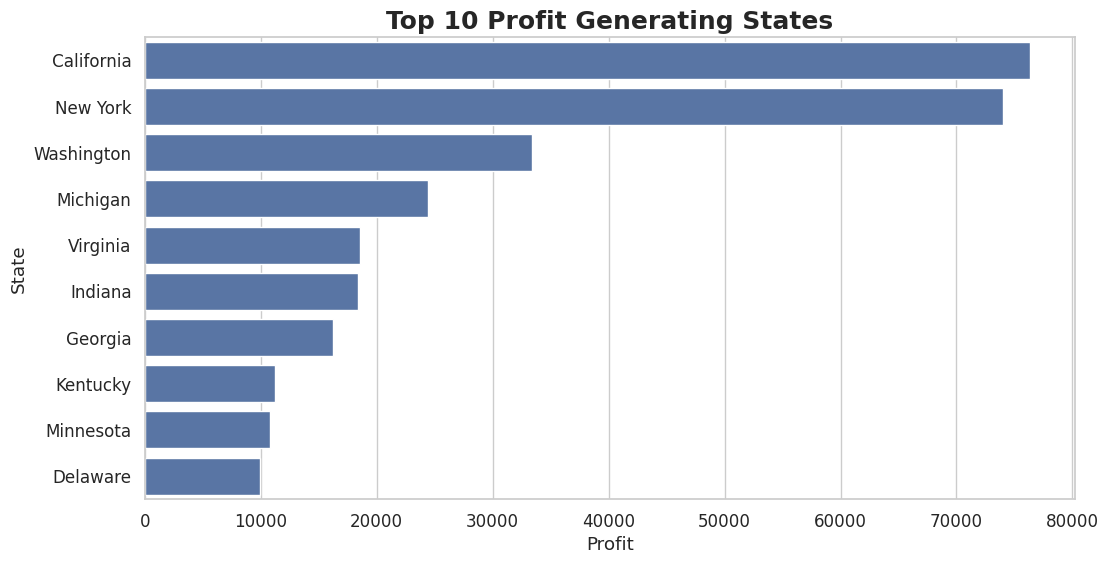

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_profit.values,
    y=state_profit.index
)

plt.title(
    'Top 10 Profit Generating States',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Profit')

plt.show()

Loss-Making States

In [ ]:
loss_states = (
    df.groupby('State')['Profit']
    .sum()
    .sort_values()
    .head(10)
)

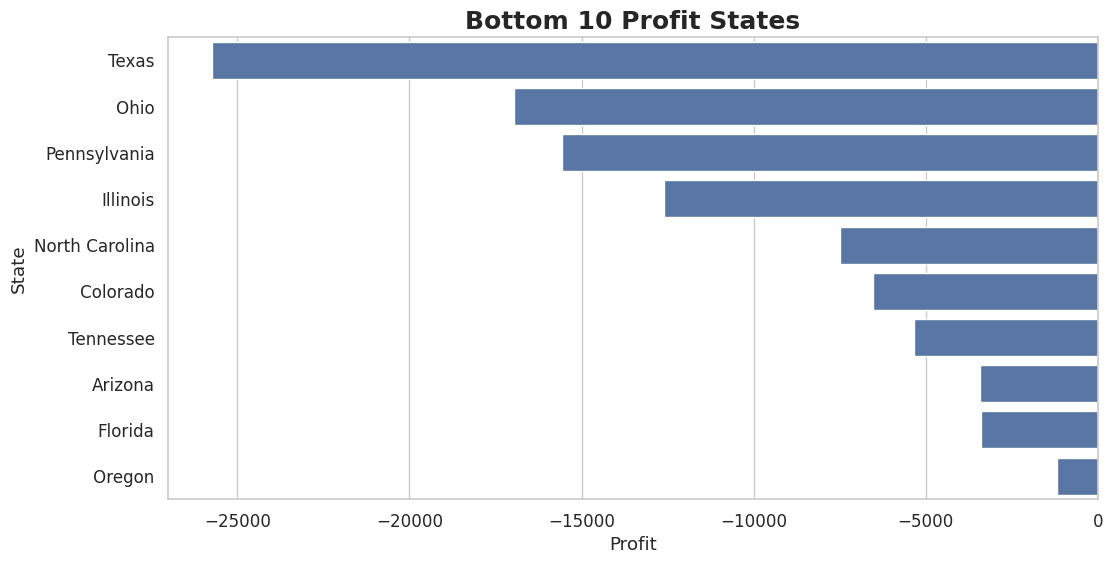

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=loss_states.values,
    y=loss_states.index
)

plt.title(
    'Bottom 10 Profit States',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Profit')

plt.show()

Discount vs Profit

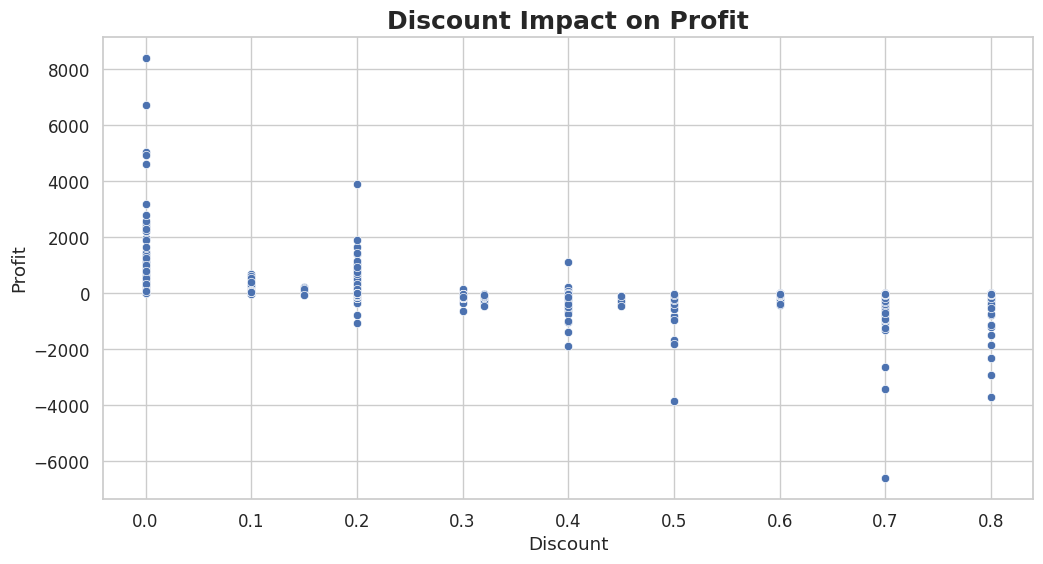

In [ ]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title(
    'Discount Impact on Profit',
    fontsize=18,
    weight='bold'
)

plt.show()

Sub-Category Performance Dashboard

In [ ]:
subcategory = (
    df.groupby('Sub-Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .sort_values(
          'Profit',
          ascending=False
      )
)

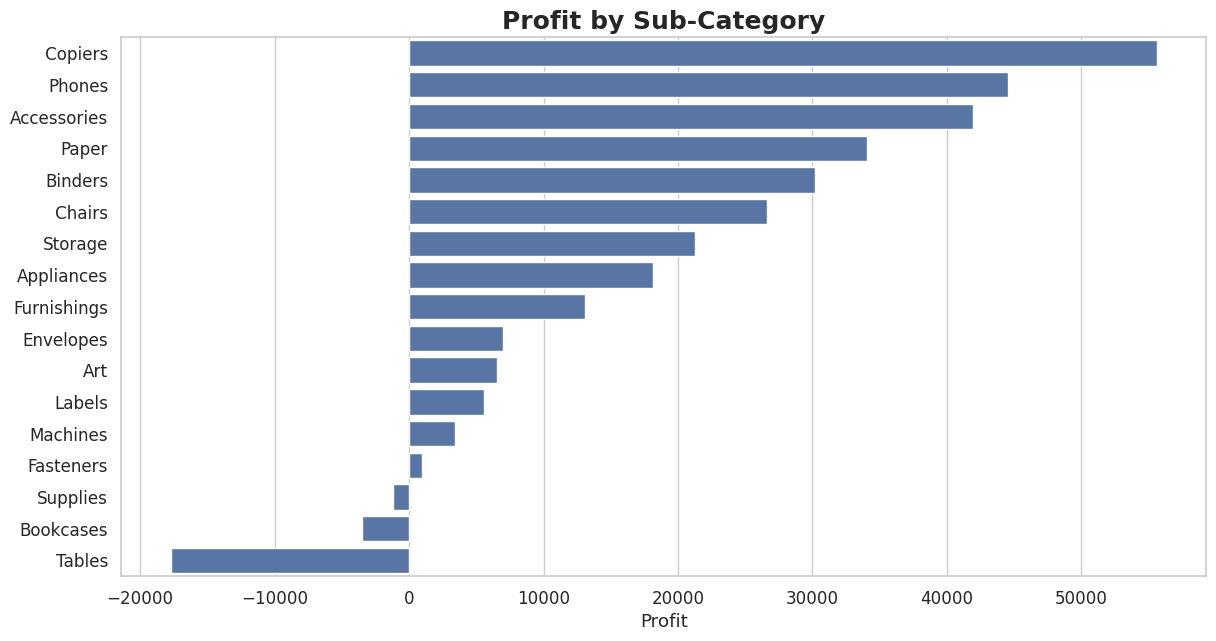

In [ ]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=subcategory.reset_index(),
    x='Profit',
    y='Sub-Category'
)

plt.title(
    'Profit by Sub-Category',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Profit')
plt.ylabel('')

plt.show()

Sales vs Profit

In [ ]:
subcategory_bubble = (
    df.groupby('Sub-Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum',
          'Quantity':'sum'
      })
      .reset_index()
)

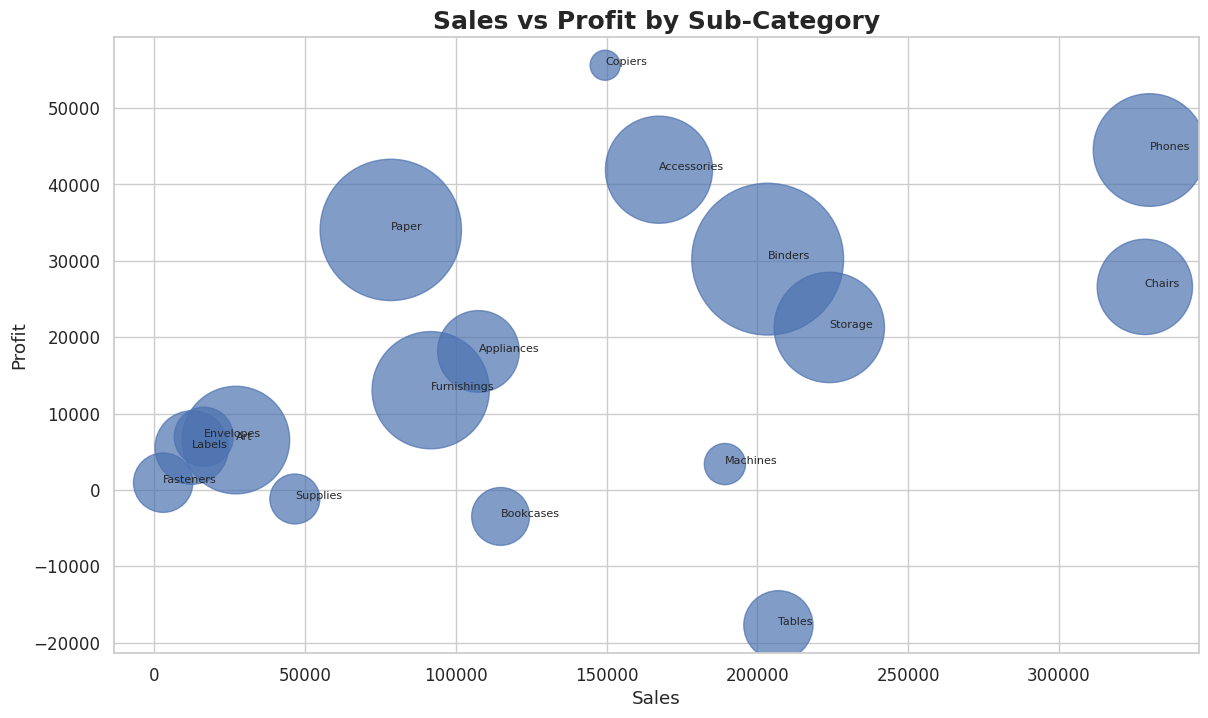

In [ ]:
plt.figure(figsize=(14,8))

plt.scatter(
    subcategory_bubble['Sales'],
    subcategory_bubble['Profit'],
    s=subcategory_bubble['Quantity']*2,
    alpha=0.7
)

for i in range(len(subcategory_bubble)):
    plt.text(
        subcategory_bubble['Sales'][i],
        subcategory_bubble['Profit'][i],
        subcategory_bubble['Sub-Category'][i],
        fontsize=8
    )

plt.title(
    'Sales vs Profit by Sub-Category',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

Customer Segment Performance

In [ ]:
segment = (
    df.groupby('Segment')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .reset_index()
)

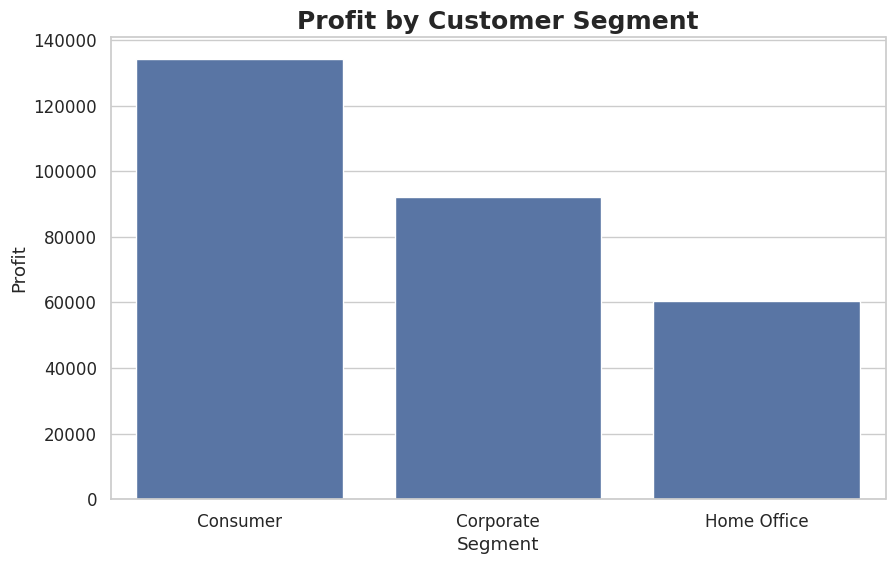

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=segment,
    x='Segment',
    y='Profit'
)

plt.title(
    'Profit by Customer Segment',
    fontsize=18,
    weight='bold'
)

plt.show()

Executive Insight Heatmap

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Profit',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

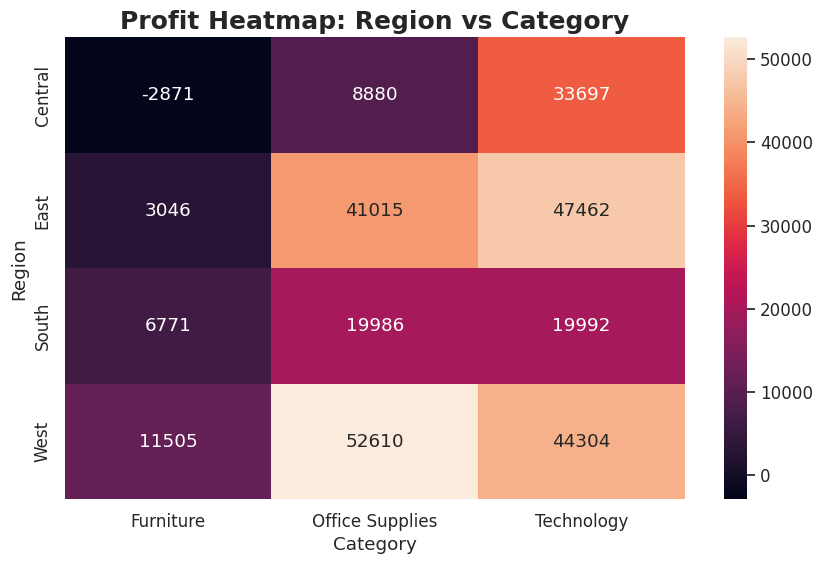

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f'
)

plt.title(
    'Profit Heatmap: Region vs Category',
    fontsize=18,
    weight='bold'
)

plt.show()

Profitability Quadrant Analysis

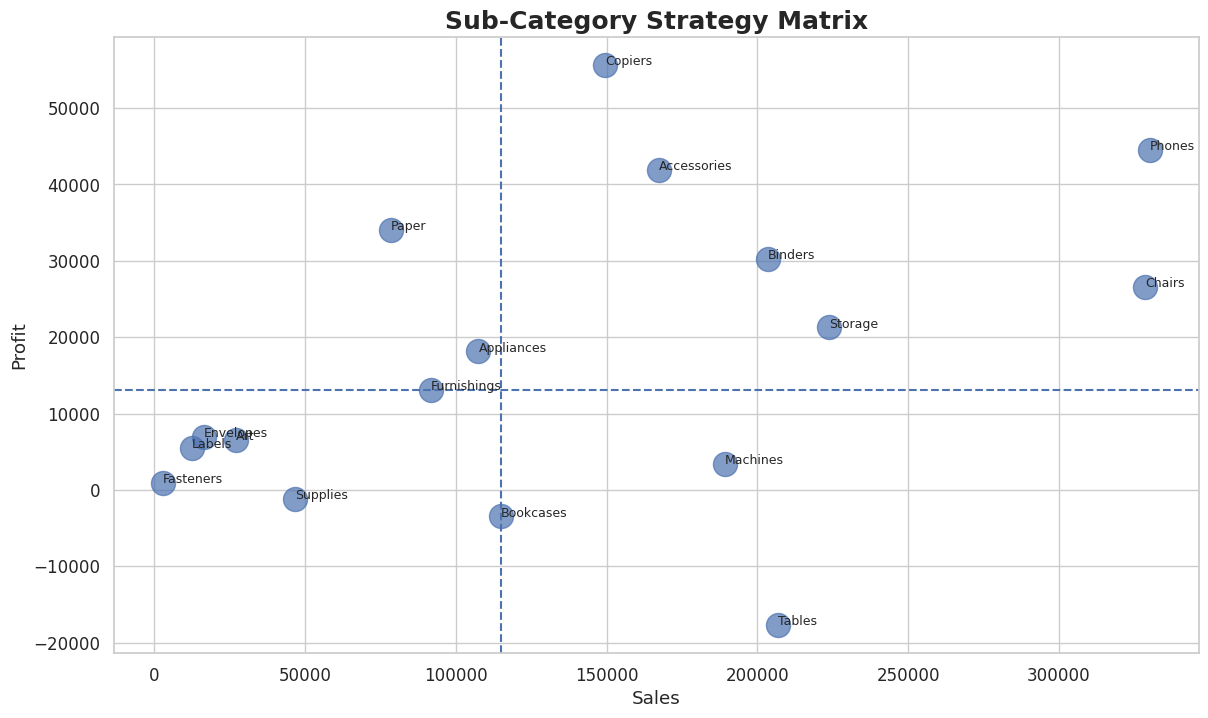

In [ ]:
subcategory = (
    df.groupby('Sub-Category')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
    .reset_index()
)

sales_median = subcategory['Sales'].median()
profit_median = subcategory['Profit'].median()

plt.figure(figsize=(14,8))

plt.scatter(
    subcategory['Sales'],
    subcategory['Profit'],
    s=300,
    alpha=0.7
)

plt.axvline(
    sales_median,
    linestyle='--'
)

plt.axhline(
    profit_median,
    linestyle='--'
)

for i in range(len(subcategory)):
    plt.annotate(
        subcategory['Sub-Category'][i],
        (
            subcategory['Sales'][i],
            subcategory['Profit'][i]
        ),
        fontsize=9
    )

plt.title(
    'Sub-Category Strategy Matrix',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Sales')
plt.ylabel('Profit')

plt.show()

Discount vs Profit Trend

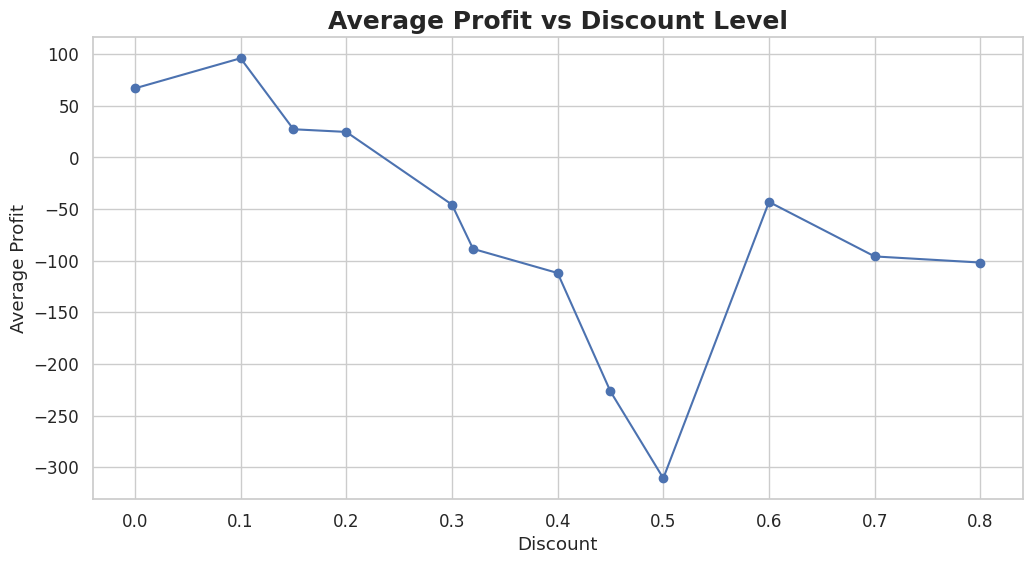

In [ ]:
discount_profit = (
    df.groupby('Discount')
    .agg({
        'Profit':'mean'
    })
    .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    discount_profit['Discount'],
    discount_profit['Profit'],
    marker='o'
)

plt.title(
    'Average Profit vs Discount Level',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Discount')
plt.ylabel('Average Profit')

plt.grid(True)

plt.show()

Top Revenue vs Loss Comparison

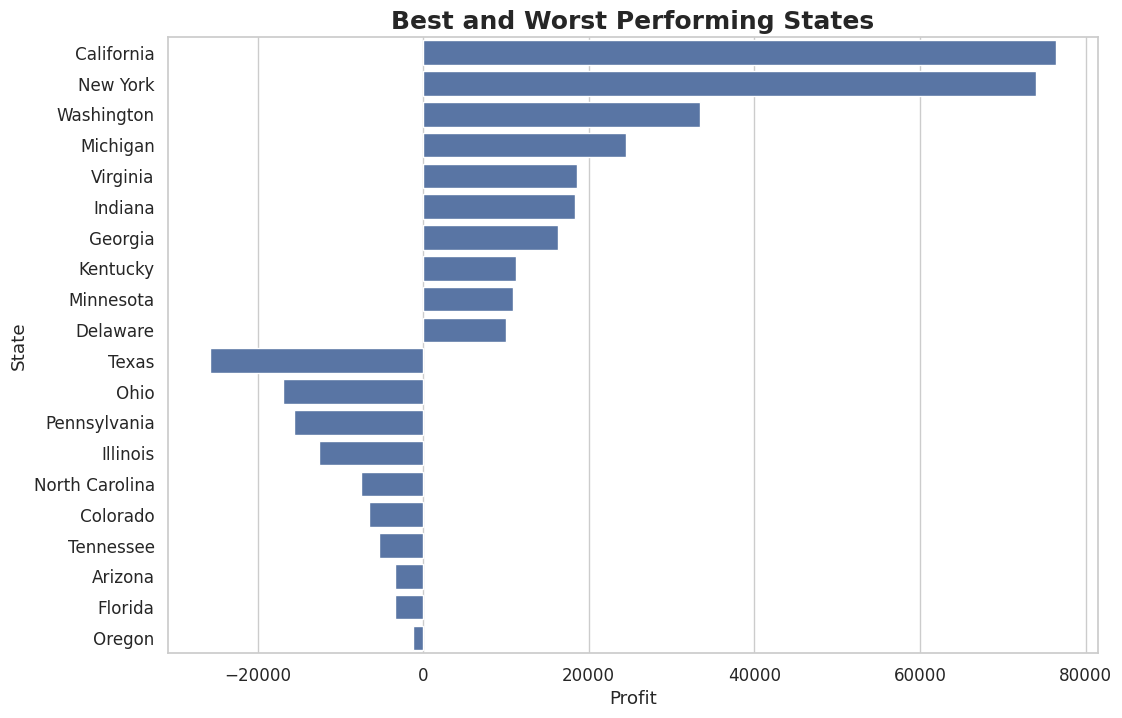

In [ ]:
state_compare = (
    df.groupby('State')
    .agg({
        'Profit':'sum'
    })
)

top_states = (
    state_compare
    .sort_values(
        'Profit',
        ascending=False
    )
    .head(10)
)

bottom_states = (
    state_compare
    .sort_values(
        'Profit'
    )
    .head(10)
)

comparison = pd.concat([
    top_states,
    bottom_states
])

plt.figure(figsize=(12,8))

sns.barplot(
    x='Profit',
    y=comparison.index,
    data=comparison.reset_index()
)

plt.title(
    'Best and Worst Performing States',
    fontsize=18,
    weight='bold'
)

plt.show()

Revenue Leak Analysis

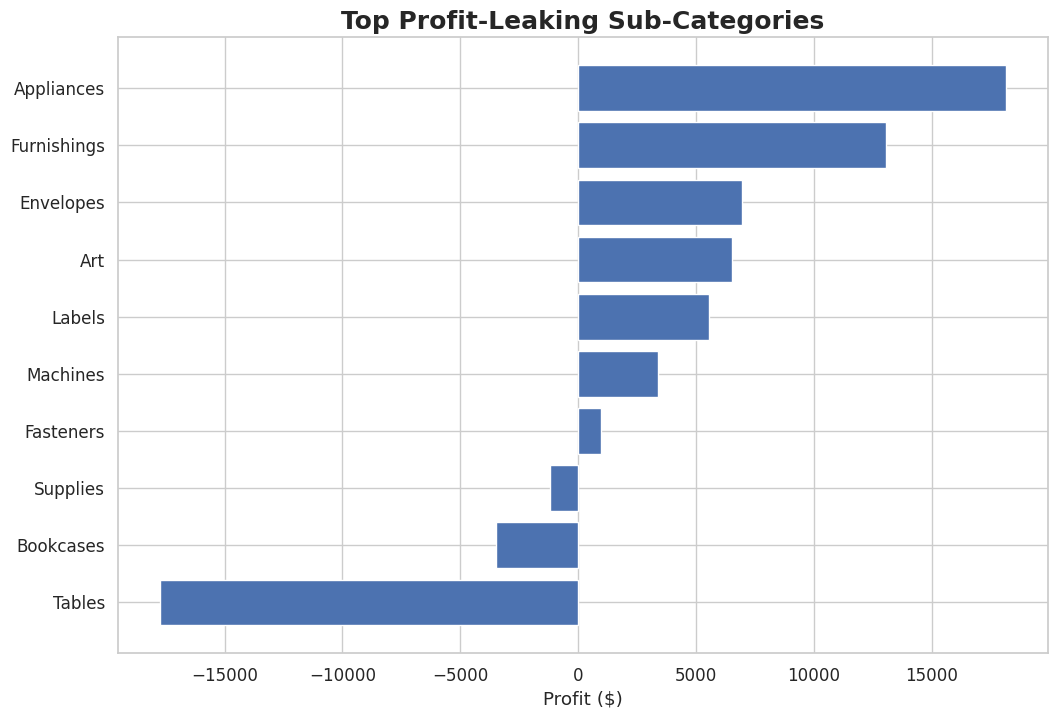

In [ ]:
loss_subcat = (
    df.groupby('Sub-Category')
    .agg({
        'Profit':'sum'
    })
    .sort_values('Profit')
)

plt.figure(figsize=(12,8))

plt.barh(
    loss_subcat.head(10).index,
    loss_subcat.head(10)['Profit']
)

plt.title(
    'Top Profit-Leaking Sub-Categories',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Profit ($)')

plt.show()

Customer Concentration Analysis

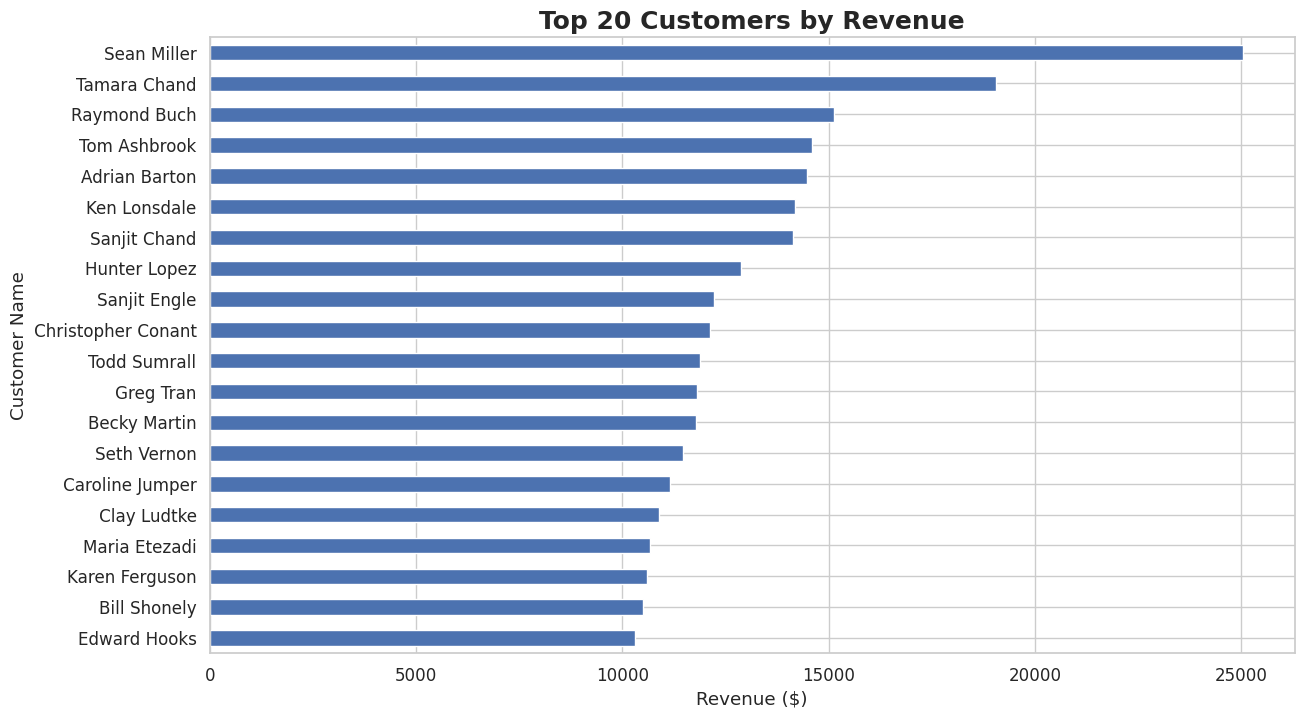

In [ ]:
customer_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(14,8))

customer_sales.sort_values().plot(
    kind='barh'
)

plt.title(
    'Top 20 Customers by Revenue',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Revenue ($)')

plt.show()

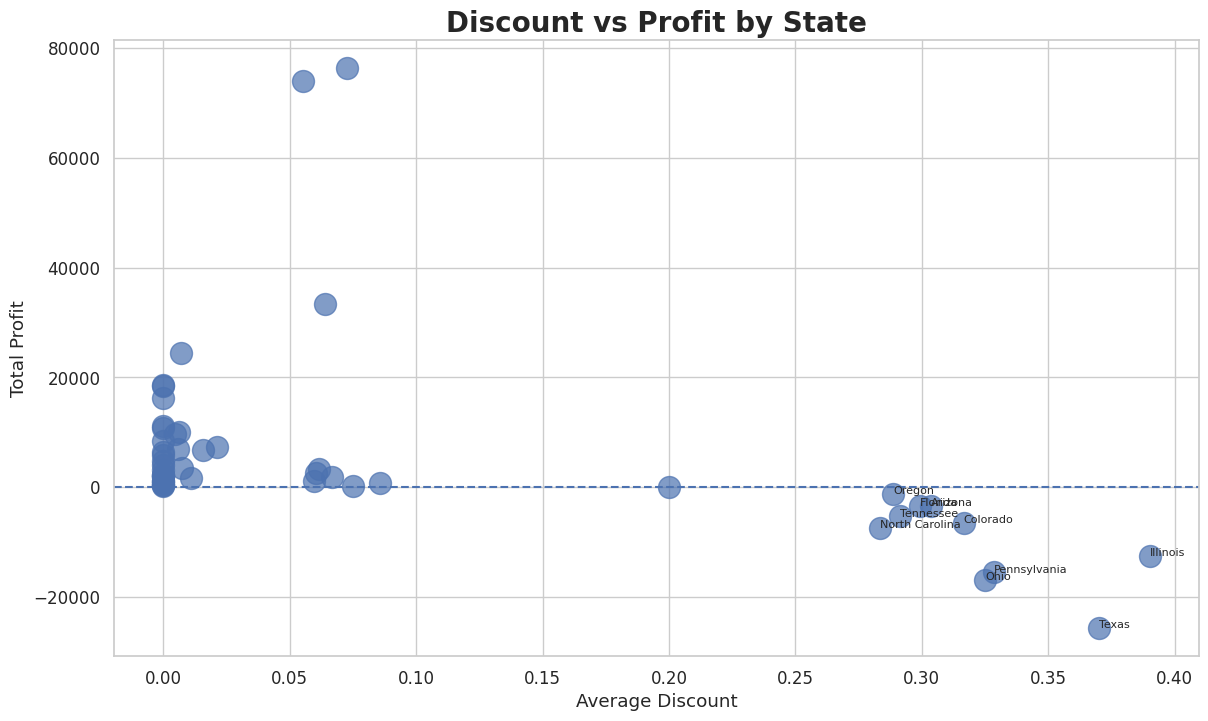

In [ ]:
state_discount = (
    df.groupby('State')
    .agg({
        'Discount':'mean',
        'Profit':'sum'
    })
)

plt.figure(figsize=(14,8))

plt.scatter(
    state_discount['Discount'],
    state_discount['Profit'],
    s=250,
    alpha=0.7
)

for state in state_discount.index:
    if state_discount.loc[state,'Profit'] < 0:
        plt.annotate(
            state,
            (
                state_discount.loc[state,'Discount'],
                state_discount.loc[state,'Profit']
            ),
            fontsize=8
        )

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(
    'Discount vs Profit by State',
    fontsize=20,
    weight='bold'
)

plt.xlabel('Average Discount')
plt.ylabel('Total Profit')

plt.show()

Profit Contribution by Category

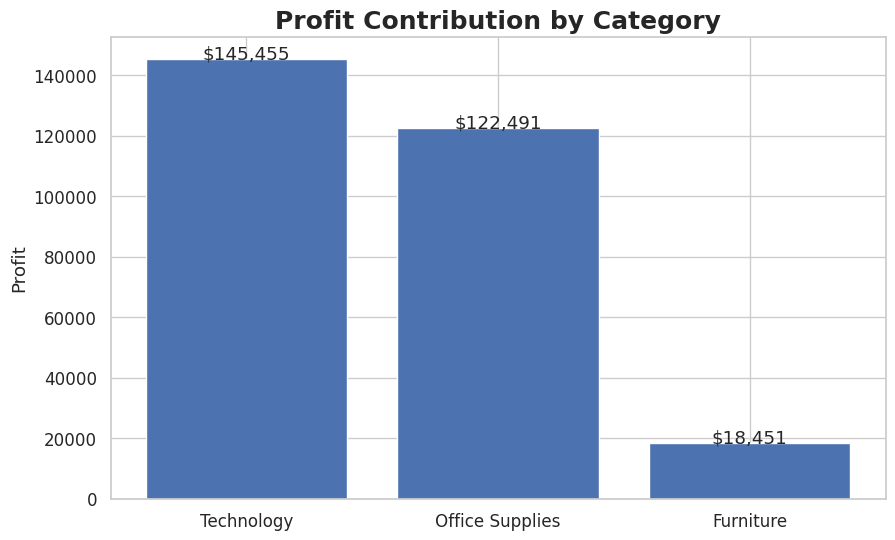

In [ ]:
category_profit = (
    df.groupby('Category')['Profit']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

bars = plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title(
    'Profit Contribution by Category',
    fontsize=18,
    weight='bold'
)

plt.ylabel('Profit')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha='center'
    )

plt.show()

Year-over-Year Growth

In [ ]:
# Convert dates

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year column

df['Order Year'] = df['Order Date'].dt.year

print(df[['Order Date','Order Year']].head())

  Order Date  Order Year
0 2016-11-08        2016
1 2016-11-08        2016
2 2016-06-12        2016
3 2015-10-11        2015
4 2015-10-11        2015


,Sales,Profit
Order Year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


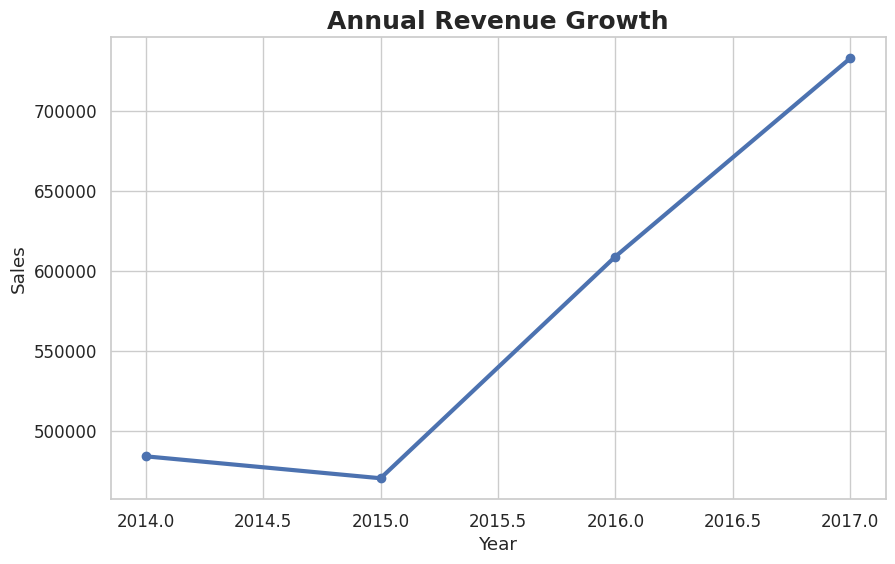

In [ ]:
yearly = (
    df.groupby('Order Year')
    .agg({
        'Sales':'sum',
        'Profit':'sum'
    })
)

display(yearly)

yearly['Sales Growth %'] = (
    yearly['Sales']
    .pct_change()
    * 100
)

plt.figure(figsize=(10,6))

plt.plot(
    yearly.index,
    yearly['Sales'],
    marker='o',
    linewidth=3
)

plt.title(
    'Annual Revenue Growth',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Year')
plt.ylabel('Sales')

plt.grid(True)

plt.show()